den store fil 

## vi har nu:

# Preprocessing
import af alle predictors
averaging til én værdi per år
kombination baseret på valgåret

# modelling
en simpel OLS model - med flere sæt predictors

# evaluation
En LOOCV



### vi mangler:
# Preprocessing
(en mere sofistikeret vægtning når flere  målinger pr år)
interpolation af manglende år
kombination baseret på alle år, evt baseret på vægte estimeret ved regression (eller en model der kan have en højere resolution i x end i y)

# Modelling
En analyse af colinearity/kombination af variable for at komme af med den
en ols model rafineret efter chapt 6
en form for bayesian regression eller noget?
En form for tree based method - BART?
lasso?  - måske skal vi lave en lasso for alle predictors, og en for kun økonomiske? sådan at vi kan lave økonomiske og wellbeing sammenligningen
lasso med crossvalidation for at ifnde maximum - vi må hellere få lavet den rette
PCA på ecoonomics?

vi har high dimensions

# Evaluation
En leave future out validation (der er mange valg her fx ift om man kun skal evaluere på nogle få valg og om man skal fjerne det seenste)

en analyse af hvilke predictors der er vigtige og hvad det  btyder

# Setup

In [1]:
# install libraries

In [68]:
# import libraries
import numpy as np
import pandas as pd
from matplotlib.pyplot import subplots
import os
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF 
import statsmodels.api as sm
from ISLP import load_data
from ISLP.models import (ModelSpec as MS ,
summarize ,
poly)
from functools import partial
from sklearn.base import clone
from ISLP.models import sklearn_sm
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from ISLP.bart import BART

In [3]:
# check working directory
os.getcwd()

'c:\\Users\\carle\\Documents\\Cognitive_Science\\MASTER\\Data science\\Data science exam\\data_science'

# Data wrangling and dataset creation

In [4]:
# load data
gini = pd.read_csv('data/gini.csv', index_col=0, skiprows=3) # gini coefficient
gdp = pd.read_csv('data/gdp.csv', index_col=0, skiprows=3) # GDP
inflation = pd.read_csv('data/inflation.csv', index_col=0, skiprows=3) # inflation rate
unemployment = pd.read_csv('data/unemployment.csv', index_col=0, skiprows=3) # unemployment rate
income = pd.read_csv('data/Real wage.csv') # median real earnings
satisfaction = pd.read_csv('data/satisfaction.csv') # satsifaction with personal life and with the US
election_results = pd.read_csv('data/election_results.csv') # electoral outcomes

### Inspect data

In [5]:
gini


,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Eastern and Southern,AFE,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Afghanistan,AFG,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Western and Central,AFW,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Angola,AGO,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,51.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,44.2,44.6,40.2,57.4,49.4,38.3,NaN,NaN,NaN,NaN
"Yemen, Rep.",YEM,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,Gini index,SI.POV.GINI,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,54.1,NaN,NaN,NaN,NaN


In [6]:
gdp

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.485815,3.048518,0.951664,-23.466273,15.675519,11.038520,7.657640,6.181751,NaN,NaN
Africa Eastern and Southern,AFE,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,-2.182395,5.075379,2.795642,1.790384,2.225029,1.922442,...,0.000238,-0.064991,-0.709407,-5.405934,1.844404,1.068005,-0.604582,0.253854,NaN,NaN
Afghanistan,AFG,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-0.195570,-1.713743,0.856295,-5.382515,-22.584482,-7.576669,0.106093,NaN,NaN,NaN
Africa Western and Central,AFW,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,-0.251185,1.538542,4.740660,3.086962,1.823450,-3.703529,...,-0.355283,0.330202,0.792058,-6.003416,0.154018,2.064401,1.218110,2.107058,NaN,NaN
Angola,AGO,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-3.622865,-3.968525,-3.529000,-7.127615,-1.094341,0.991407,-1.808703,1.292933,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.038389,3.057529,5.236697,-5.406902,10.998140,5.339098,9.351075,10.365649,NaN,NaN
"Yemen, Rep.",YEM,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-7.888612,-2.186490,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,GDP per capita growth (annual %),NY.GDP.PCAP.KD.ZG,NaN,0.971242,3.066160,4.168016,4.692929,2.909441,1.252170,...,0.498696,-0.137485,-1.380361,-7.678733,3.255620,0.625217,-0.523851,-0.713538,NaN,NaN


In [7]:
inflation

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,-1.028282,3.626041,4.257462,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Eastern and Southern,AFE,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,6.221375,4.689806,4.102851,5.191629,6.824727,10.883478,7.399186,4.770857,NaN,NaN
Afghanistan,AFG,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.975952,0.626149,2.302373,5.601888,5.133203,13.712102,-4.644709,-6.601186,NaN,NaN
Africa Western and Central,AFW,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.725486,1.784050,1.983092,2.490378,3.745568,7.949251,5.221168,3.608044,NaN,NaN
Angola,AGO,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,29.844480,19.628938,17.080954,22.271539,25.754295,21.355290,13.644102,28.240495,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.488234,1.053798,2.675992,0.198228,3.353691,11.580510,4.944324,1.619450,NaN,NaN
"Yemen, Rep.",YEM,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,"Inflation, consumer prices (annual %)",FP.CPI.TOTL.ZG,1.288877,2.102351,1.246275,1.337971,2.534989,4.069019,3.489237,...,5.186187,4.509873,4.102851,3.232388,4.618745,7.039873,6.075244,4.361152,NaN,NaN


In [8]:
unemployment

,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,1966,...,2017,2018,2019,2020,2021,2022,2023,2024,2025,Unnamed: 70
Country Name,,,,,,,,,,,,,,,,,,,,,
Aruba,ABW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Africa Eastern and Southern,AFE,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Afghanistan,AFG,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,11.184000,NaN,NaN,11.710,5.679,NaN,NaN,NaN,NaN,NaN
Africa Western and Central,AFW,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.240084,NaN,3.689777,NaN,NaN,3.337512,NaN,NaN,NaN,NaN
Angola,AGO,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,16.431000,16.033,15.806,14.094000,12.885,13.937,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Kosovo,XKX,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,30.344000,27.761,25.069000,25.459,20.392,12.093000,10.533,10.834,NaN,NaN
"Yemen, Rep.",YEM,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
South Africa,ZAF,"Unemployment, total (% of total labor force) (...",SL.UEM.TOTL.NE.ZS,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,27.035000,26.906,28.468000,29.217,34.007,33.268000,32.098,32.279,NaN,NaN


In [9]:
income

,observation_date,LES1252881600Q
0,1979-01-01,335.0
1,1979-04-01,335.0
2,1979-07-01,330.0
3,1979-10-01,326.0
4,1980-01-01,321.0
...,...,...
184,2025-01-01,373.0
185,2025-04-01,376.0
186,2025-07-01,376.0
187,2025-10-01,NaN


In [10]:
satisfaction

,"In general, are you satisfied or dissatisfied with the way things are going in [your personal life/the United States] at this time? <br><b>% Satisfied</b>",Personal life,United States
0,1/2/2025,81,20
1,1/2/2024,78,20
2,1/2/2023,83,23
3,1/3/2022,85,17
4,1/4/2021,82,11
...,...,...,...
58,6/5/1981,81,33
59,1/9/1981,81,17
60,11/2/1979,79,19
61,7/13/1979,73,12


In [11]:
election_results

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis


### Filter, re-format and rename

#### Gini, GDP, inflation and unemployment

In [12]:
# filter rows - keep the US only
gini, gdp, inflation, unemployment = [
    df.loc[['United States']]
    for df in [gini, gdp, inflation, unemployment]
]

In [13]:
# filter columns - drop metadata
gini, gdp, inflation, unemployment = [
    df.drop(columns=["Country Code", "Indicator Name", "Indicator Code", "Unnamed: 70"])
    for df in [gini, gdp, inflation, unemployment]
]

In [14]:
# convert from wide to long format
gini, gdp, inflation, unemployment = [
    df.melt(var_name="year", value_name=name)
    for df, name in zip(
        [gini, gdp, inflation, unemployment],
        ["gini", "gdp", "inflation", "unemployment"]
    )
]

In [15]:
# convert "year" column from string to integer
gini['year'], gdp['year'], inflation['year'], unemployment['year'] = [
    df["year"].astype(int)
    for df in [gini, gdp, inflation, unemployment]
]

#### Income and satisfaction

In [16]:
# rename column
income = income.rename(columns={"LES1252881600Q": "median_real_wage"})

In [17]:
# extract year
income['year'] = income['observation_date'].str[:4]
income.head()

,observation_date,median_real_wage,year
0,1979-01-01,335.0,1979
1,1979-04-01,335.0,1979
2,1979-07-01,330.0,1979
3,1979-10-01,326.0,1979
4,1980-01-01,321.0,1980


In [18]:
# add column only with year
satisfaction['year'] = satisfaction['In general, are you satisfied or dissatisfied with the way things are going in [your personal life/the United States] at this time? <br><b>% Satisfied</b>'].str[-4:]

Det er kompliceret - man kunne(burde) optælle hvor mange målinger der er hvert år og bruge det til at kvantificere hvor sikker man er på mållingen fra det konkrete år - der er ogs noget der hedder missingforest - man kunne også bruge noget timeseries interpolation for at få seasonality i især us med

In [19]:
# take the mean of multiple observations during a single year
yearly_wage = income.groupby('year')['median_real_wage'].mean()
yearly_pers = satisfaction.groupby('year')['Personal life'].mean() # distribute satisfaction to satsfaction with personal life
yearly_us = satisfaction.groupby('year')['United States'].mean() # distribute satisfaction to satisfaction with the US

In [20]:
# convert each series into a dataframe
yearly_wage = pd.DataFrame(index= yearly_wage.index, data=yearly_wage.values, columns=['wage'])
yearly_pers = pd.DataFrame(index= yearly_pers.index, data=yearly_pers.values, columns=['pers'])
yearly_us = pd.DataFrame(index= yearly_us.index, data=yearly_us.values, columns=['us'])

In [21]:
# move year index back into a regular column
yearly_wage.reset_index(inplace=True)
yearly_pers.reset_index(inplace=True)
yearly_us.reset_index(inplace=True)


In [22]:
# make income and satisfaction integer
yearly_wage['year'] = yearly_wage['year'].astype(int)
yearly_pers['year'] = yearly_pers['year'].astype(int)
yearly_us['year'] = yearly_us['year'].astype(int)

In [23]:
# check that it worked
yearly_pers

,year,pers
0,1979,76.333333
1,1981,81.000000
2,1982,75.500000
3,1983,77.000000
4,1984,79.000000
5,1985,82.000000
6,1986,84.000000
7,1987,83.000000
8,1988,86.500000
9,1990,84.000000


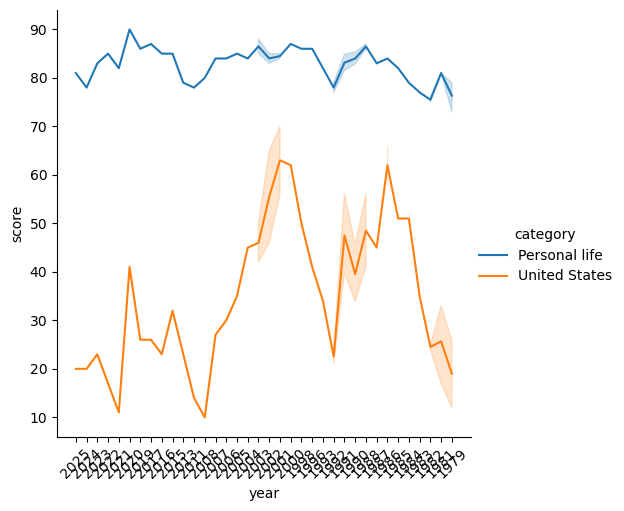

In [24]:
# Melt wide → long format
satisfaction_long = satisfaction.melt(
    id_vars="year",
    value_vars=["Personal life", "United States"],
    var_name="category",
    value_name="score"
)

# Plot with hue to separate the two lines
g = sns.relplot(
    data=satisfaction_long,
    x="year",
    y="score",
    hue="category",
    kind="line"
)

g.tick_params(axis='x', rotation=45)

### Weighted average

In [25]:
# Create function and define weights for each year of the term (most recent year = highest weight)

def weighted_term_mean(df, value_column, election_years, weights):
    results = []
    for ey in election_years:
        term_years = list(range(ey - 3, ey + 1))  # 4 years leading up to election
        term_data = df[df['year'].isin(term_years)].sort_values('year')
        
        if len(term_data) >= 1:
            w = weights[-len(term_data):]
            w_mean = np.average(term_data[f'{value_column}'].values, weights=w)
        else:
            w_mean = np.nan  # not enough data
            
        results.append({'year': ey, f'{value_column}': w_mean})
    
    return pd.DataFrame(results)

weights = [0.1, 0.2, 0.3, 0.4] # define weights



In [26]:
# Apply weight function
gini_weighted = weighted_term_mean(gini, 'gini', election_results['year'].tolist(), weights) # gini
gdp_weighted = weighted_term_mean(gdp, 'gdp', election_results['year'].tolist(), weights) # GDP
unemployment_weighted = weighted_term_mean(unemployment, 'unemployment', election_results['year'].tolist(), weights) # unemployment
inflation_weighted = weighted_term_mean(inflation, 'inflation', election_results['year'].tolist(), weights) # inflation
wage_weighted = weighted_term_mean(yearly_wage, 'wage', election_results['year'].tolist(), weights) # income
pers_weighted = weighted_term_mean(yearly_pers, 'pers', election_results['year'].tolist(), weights) # satisfaction with personal life
us_weighted = weighted_term_mean(yearly_us, 'us', election_results['year'].tolist(), weights) # satisfaction with the US


In [27]:
# check
inflation_weighted

,year,inflation
0,2024,4.485057
1,2020,1.738624
2,2016,1.011149
3,2012,2.067241
4,2008,3.375905
5,2004,2.351747
6,2000,2.551376
7,1996,2.830762
8,1992,4.044309
9,1988,3.464639


In [28]:
pers_weighted

,year,pers
0,2024,81.300000
1,2020,88.000000
2,2016,83.666667
3,2012,78.000000
4,2008,82.500000
5,2004,84.800000
6,2000,86.571429
7,1996,84.285714
8,1992,81.041667
9,1988,84.500000


### Merge data

In [29]:
# merge to single dataframe
prediction_data = pd.merge(election_results, gini_weighted, how='left', on='year') # gini
prediction_data = pd.merge(prediction_data, gdp_weighted, how = 'left', on=['year']) # GDP
prediction_data = pd.merge(prediction_data, unemployment_weighted, how = 'left', on=['year']) # unemployment
prediction_data = pd.merge(prediction_data, inflation, how = 'left', on=['year']) # inflation
prediction_data = pd.merge(prediction_data, wage_weighted, how = 'left', on=['year']) # income
prediction_data = pd.merge(prediction_data, pers_weighted, how = 'left', on=['year']) # satisaction with personal life
prediction_data = pd.merge(prediction_data, us_weighted, how = 'left', on=['year']) # satisfaction with the US


In [30]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,2.949525,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.233584,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.261583,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.069337,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.839100,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.677237,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,3.376857,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.931204,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,3.028820,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,4.077741,326.175,84.500000,50.400000


Sjovt at se at de her værdier er væsentligt anderledes end lineær interpolation

### Standardization and reformatting

In [31]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,2.949525,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.233584,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.261583,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.069337,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.839100,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.677237,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,3.376857,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.931204,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,3.028820,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,4.077741,326.175,84.500000,50.400000


In [32]:
# drop missing values
prediction_data = prediction_data.dropna()

In [33]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,1,1,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,2.949525,366.700,81.300000,19.400000
1,2020,1,1,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.233584,365.250,88.000000,32.666667
2,2016,3,1,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.261583,341.275,83.666667,26.000000
3,2012,2,2,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.069337,337.600,78.000000,14.000000
4,2008,3,1,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.839100,334.450,82.500000,21.600000
5,2004,2,2,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.677237,337.350,84.800000,49.200000
6,2000,3,1,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,3.376857,328.275,86.571429,56.857143
7,1996,2,2,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.931204,314.175,84.285714,38.000000
8,1992,4,2,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,3.028820,314.750,81.041667,34.623457
9,1988,3,1,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,4.077741,326.175,84.500000,50.400000


In [34]:
# standardize
#scaled_prediction_data = prediction_data.copy()

#cols_to_scale = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us']  # standardizing predictors that are not categroical and the outcome

#sc = StandardScaler()
#scaled_prediction_data[cols_to_scale] = sc.fit_transform(scaled_prediction_data[cols_to_scale])

#scaled_prediction_data

In [35]:
# check types
prediction_data.dtypes

year                                                        int64
prospective conscutive term for incumbent party             int64
prospective 1st/2nd term for incumbent party candidate      int64
incumbent party                                            object
popular vote for incumbent party                          float64
popular vote for non-incumbent party                      float64
winner party                                               object
winner president                                           object
loser                                                      object
gini                                                      float64
gdp                                                       float64
unemployment                                              float64
inflation                                                 float64
wage                                                      float64
pers                                                      float64
us        

In [36]:
# make ordinal
enc = OrdinalEncoder(categories=[['1', '2', '3', '4']])  # specify order
prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(prediction_data[['prospective conscutive term for incumbent party']])

enc = OrdinalEncoder(categories=[['1', '2']])  # specify order
prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(prediction_data[['prospective 1st/2nd term for incumbent party candidate']]) #maybe we should introduce a varibale reflecting the presence of populist candidates, or something regaridn the non-incumbent candidates

C:\Users\carle\AppData\Local\Temp\ipykernel_23860\4048338162.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['prospective conscutive term for incumbent party'] = enc.fit_transform(prediction_data[['prospective conscutive term for incumbent party']])
C:\Users\carle\AppData\Local\Temp\ipykernel_23860\4048338162.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  prediction_data['prospective 1st/2nd term for incumbent party candidate'] = enc.fit_transform(prediction_data[['prospective 1st/2

In [37]:
# check
prediction_data

,year,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
0,2024,0.0,0.0,Democratic,48.34,49.81,Republican,Donald Trump,Kamala Harris,41.57,2.301963,3.9651,2.949525,366.700,81.300000,19.400000
1,2020,0.0,0.0,Republican,46.86,51.31,Democratic,Joe Biden,Donald Trump,41.07,0.240209,5.5374,1.233584,365.250,88.000000,32.666667
2,2016,2.0,0.0,Democratic,48.20,46.20,Republican,Donald Trump,Hillary Clinton,41.40,1.524295,5.5027,1.261583,341.275,83.666667,26.000000
3,2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.069337,337.600,78.000000,14.000000
4,2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.839100,334.450,82.500000,21.600000
5,2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.677237,337.350,84.800000,49.200000
6,2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,3.376857,328.275,86.571429,56.857143
7,1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.931204,314.175,84.285714,38.000000
8,1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,3.028820,314.750,81.041667,34.623457
9,1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,4.077741,326.175,84.500000,50.400000


In [38]:
# make years index
prediction_data = prediction_data.set_index('year')

In [39]:
# make years in ascending order
prediction_data = prediction_data.sort_index()

In [40]:
# check
prediction_data

,prospective conscutive term for incumbent party,prospective 1st/2nd term for incumbent party candidate,incumbent party,popular vote for incumbent party,popular vote for non-incumbent party,winner party,winner president,loser,gini,gdp,unemployment,inflation,wage,pers,us
year,,,,,,,,,,,,,,,
1980,1.0,1.0,Democratic,41.00,50.70,Republican,Ronald Reagan,Jimmy Carter,34.83,1.368685,6.5100,13.549202,323.500,76.333333,19.000000
1984,1.0,1.0,Republican,58.80,40.60,Republican,Ronald Reagan,Walter Mondale,37.00,3.221044,8.5800,4.300535,313.250,77.900000,38.366667
1988,2.0,0.0,Republican,53.60,45.60,Republican,George H. W. Bush,Michael Dukakis,37.52,2.881584,6.1800,4.077741,326.175,84.500000,50.400000
1992,3.0,1.0,Republican,37.40,43.00,Democratic,Bill Clinton,George H. W. Bush,38.24,0.826467,6.6900,3.028820,314.750,81.041667,34.623457
1996,1.0,1.0,Democratic,49.20,40.70,Democratic,Bill Clinton,Bob Dole,40.13,2.162458,5.7892,2.931204,314.175,84.285714,38.000000
2000,2.0,0.0,Democratic,48.40,47.90,Republican,George W. Bush,Al Gore,40.09,3.222102,4.2647,3.376857,328.275,86.571429,56.857143
2004,1.0,1.0,Republican,50.70,48.30,Republican,George W. Bush,John Kerry,40.58,1.879583,5.6380,2.677237,337.350,84.800000,49.200000
2008,2.0,0.0,Republican,45.70,52.90,Democratic,Barack Obama,John McCain,41.24,0.592999,5.1332,3.839100,334.450,82.500000,21.600000
2012,1.0,1.0,Democratic,51.10,47.20,Democratic,Barack Obama,Mitt Romney,40.97,0.842423,8.7643,2.069337,337.600,78.000000,14.000000


SÅ ER DATAEN FÆRDIG

# Exploratory analysis

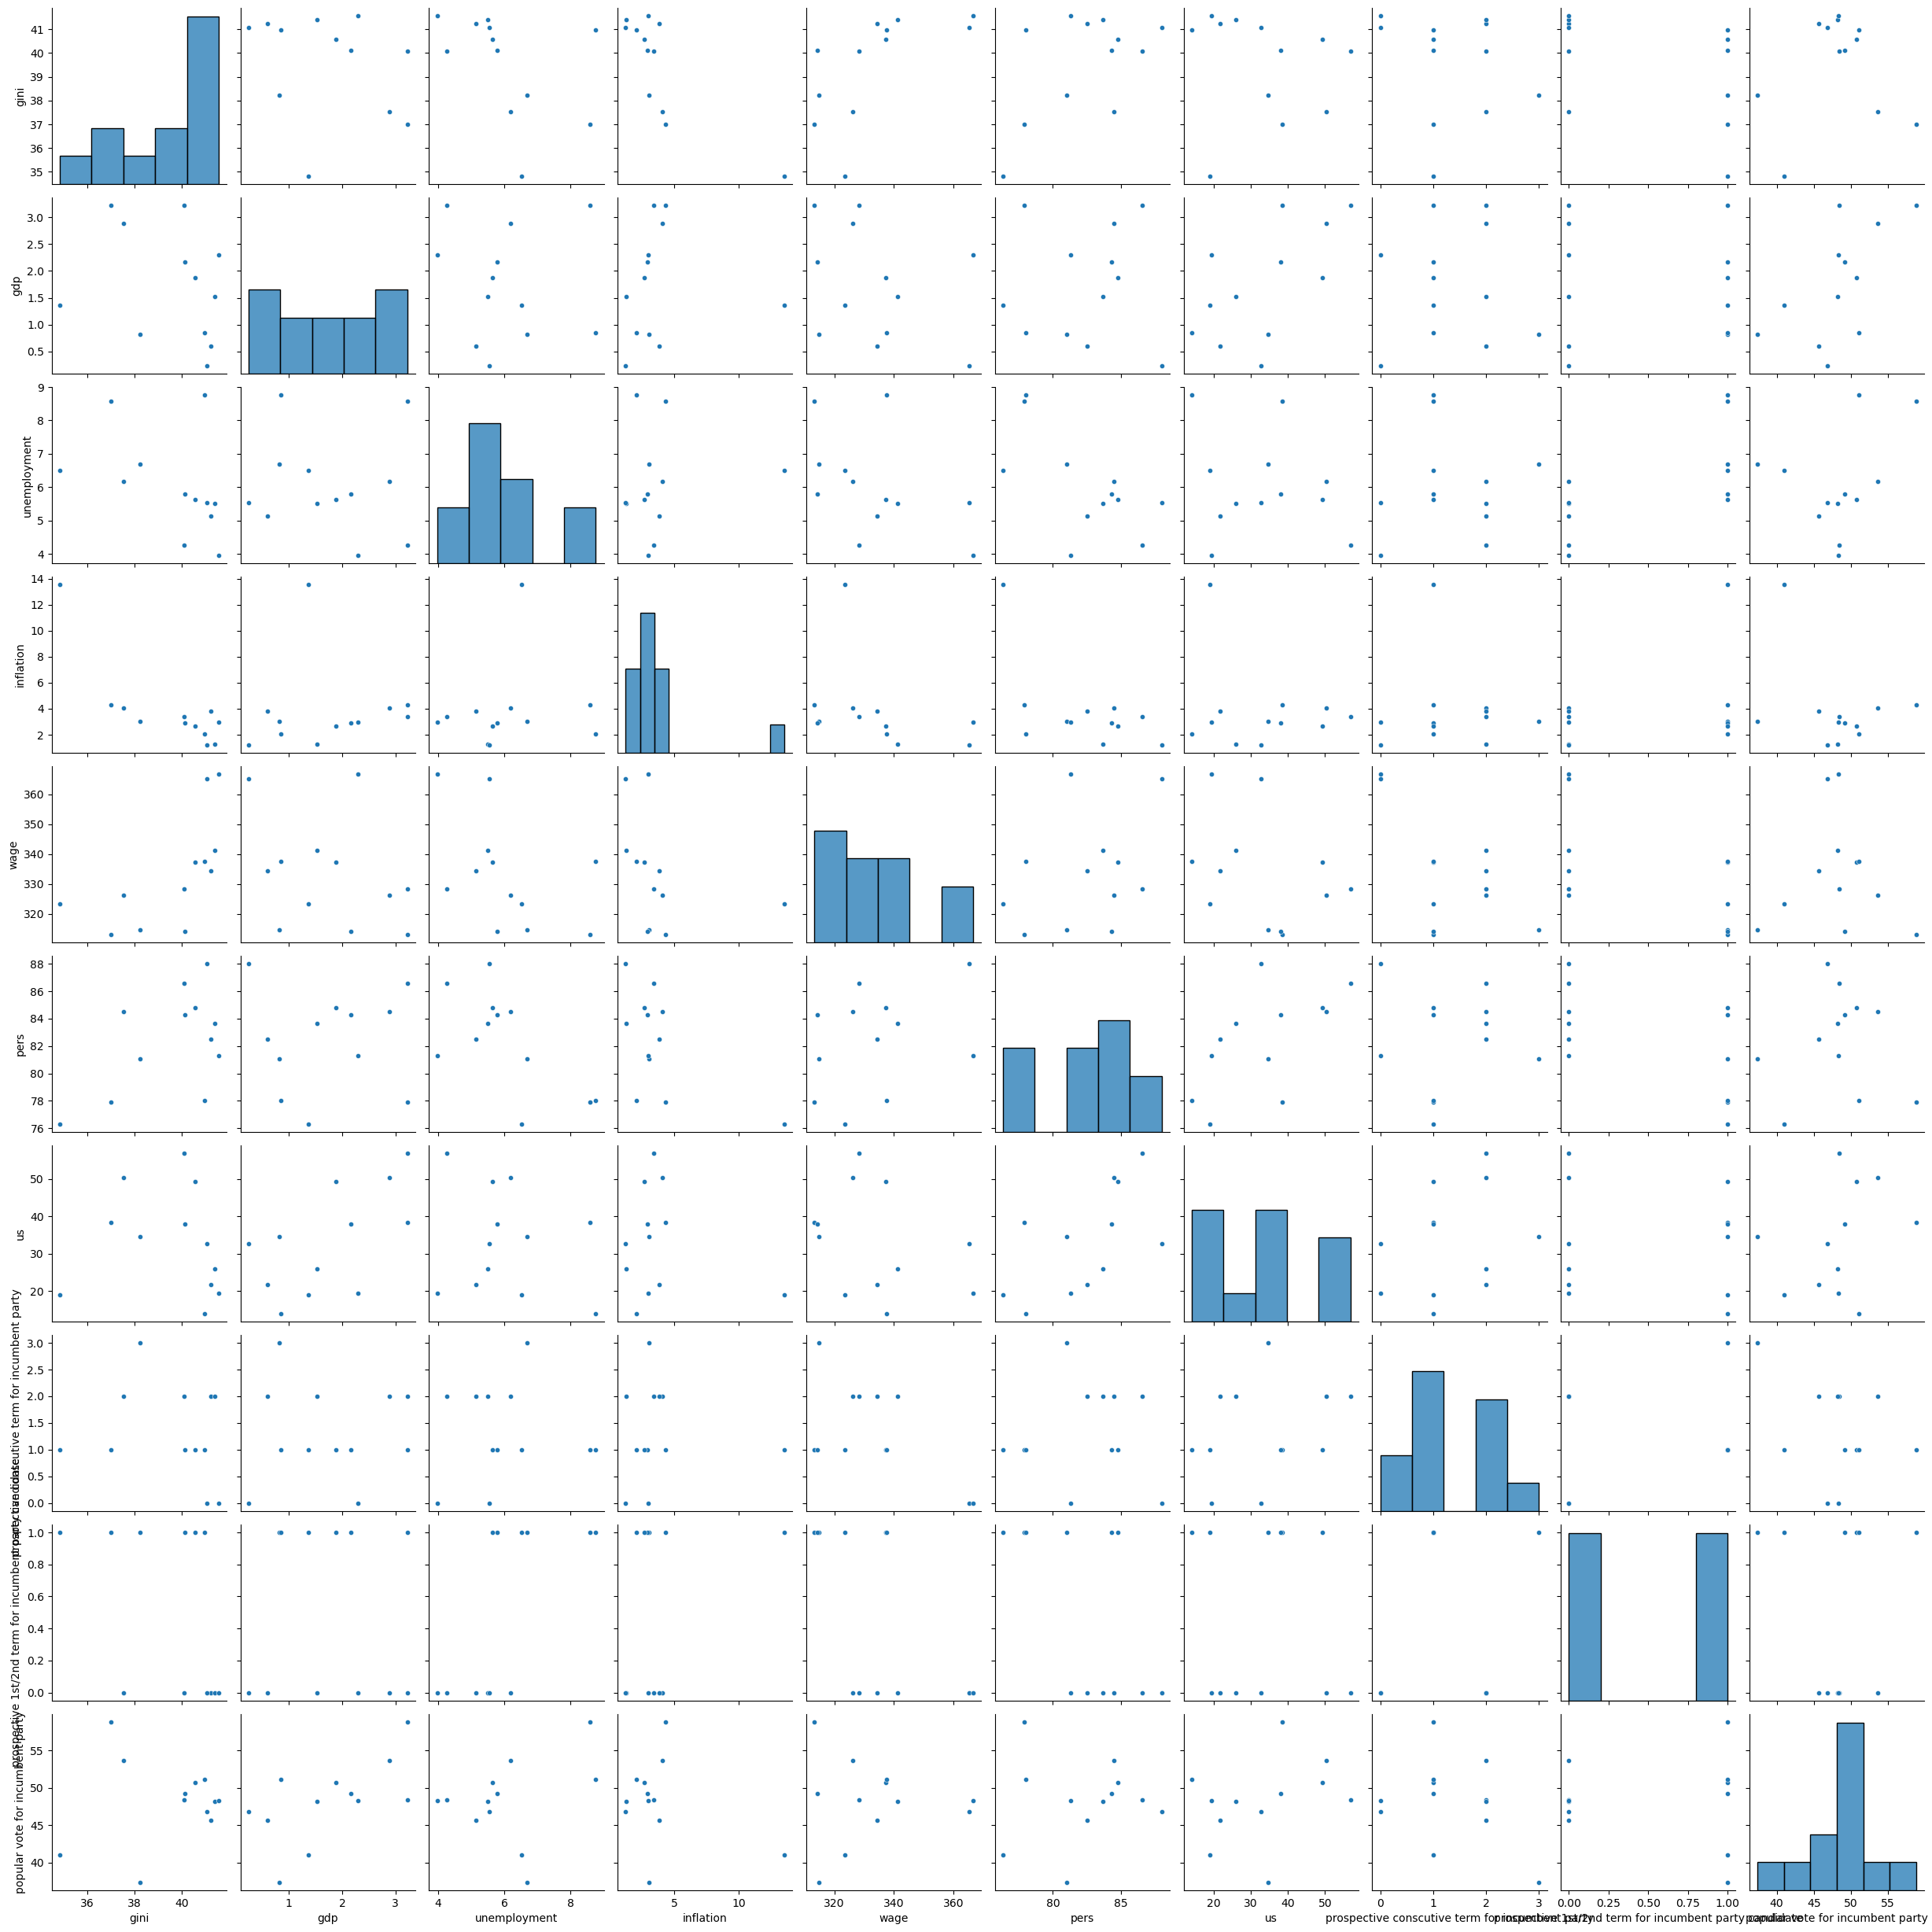

In [41]:
# plot colinearity



cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate', 'popular vote for incumbent party']

sns.pairplot(prediction_data[cols], plot_kws={'alpha': 1, 's': 20})
plt.show()

In [42]:
# calculate colinearity with VIF

In [43]:
# skal dette vær escaled?
X = scaled_prediction_data[['gdp', 'inflation', 'unemployment', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

NameError: name 'scaled_prediction_data' is not defined

In [ ]:
vals = [VIF(X, i)  
    for i in range(1, X.shape[1])] 
vif = pd.DataFrame({'vif':vals},  
    index=X.columns[1:]) 
vif

,vif
inflation,1.101314
unemployment,1.505223
prospective conscutive term for incumbent party,1.858553
prospective 1st/2nd term for incumbent party candidate,2.497600


problems from the book:
1. Non-linearity of the response-predictor relationships. 
2. Correlation of error terms. 
3. Non-constant variance of error terms. 
4. Outliers. 
5. High-leverage points. 
6. Collinearity. - decreases accuracy -indentifiability problems
and thus rreduces power of the test, increases p values

## linear regression: 


In [ ]:
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]

In [54]:
# Null model
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = []

pipe = Pipeline([
    ('features', MS(cols)),
    ('scaler', StandardScaler()),
    ('model', sklearn_sm(sm.OLS, MS(cols)))
])

tss = TimeSeriesSplit(n_splits=6)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-4.319947049030811


{'fit_time': array([0.01612306, 0.02070928, 0.01085544, 0.0099895 , 0.02062201,
        0.01372743]),
 'score_time': array([0.00699973, 0.00499415, 0.00558615, 0.00332642, 0.00313091,
        0.00363517]),
 'test_score': array([-6.93444444e+00, -7.52326531e+00, -9.00000000e+00, -5.44444444e-02,
        -2.40250000e+00, -5.02809917e-03])}

In [ ]:
# null model prdeicting last elections
cols = []

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 2
model = sklearn_sm(sm.OLS, MS(cols))
model.fit(X_train, Y_train)
predictions = model.predict(X_test)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions.values
}, index=Y_test.index)

print(results_df)
print(mse)

      Actual  Predicted
year                   
2016   48.20  48.433333
2020   46.86  48.433333
2024   48.34  48.433333
0.8461777777777736


In [55]:
# all predictors model
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', LinearRegression(fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=6)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-114.35868078974148


{'fit_time': array([0.00917554, 0.00929689, 0.00900388, 0.00796413, 0.01335454,
        0.00538778]),
 'score_time': array([0.00589275, 0.00459623, 0.00479031, 0.00523448, 0.0030086 ,
        0.00312281]),
 'test_score': array([ -26.3113383 ,  -51.59529122,  -65.14824705,   -4.24225515,
        -511.85408384,  -27.00086918])}

In [ ]:
# all predictors model prdeicting last elections
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 2
model = sklearn_sm(sm.OLS, MS(cols))
model.fit(X_train, Y_train)
predictions = model.predict(X_test)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions.values
}, index=Y_test.index)

print(results_df)
print(mse)

      Actual  Predicted
year                   
2016   48.20  23.054569
2020   46.86  50.395840
2024   48.34 -14.762846
1542.2546515138074


## NOW LASSO

In [63]:
# all predictors model
X = prediction_data[['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']]
Y = prediction_data['popular vote for incumbent party']

cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']

pipe = Pipeline([
    ('scaler', StandardScaler()),   # only scales real features, no intercept involved
    ('model', Lasso(alpha = 1, fit_intercept = True))   # handles intercept separately via fit_intercept=True
])

tss = TimeSeriesSplit(n_splits=6)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss, scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-17.834317715836203


{'fit_time': array([0.01044464, 0.00714588, 0.00902677, 0.0077827 , 0.        ,
        0.02041721]),
 'score_time': array([0.00333643, 0.00577116, 0.0054853 , 0.00468779, 0.        ,
        0.00328612]),
 'test_score': array([-32.09321992, -43.08762941, -16.22868519,  -0.96423191,
         -5.53172661,  -9.10041325])}

In [ ]:
# check coefficients importance
pipe.fit(X, Y)

coefs = pd.Series(pipe.named_steps['model'].coef_)
print(coefs)
print('intercept:', pipe.named_steps['model'].intercept_)

0    0.000000
1    2.367657
2    0.911968
3   -0.920983
4    0.000000
5    0.000000
6    0.000000
7   -0.867989
8   -0.000000
dtype: float64
intercept: 48.275000000000006


In [66]:
# all predictors model prdeicting last elections
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us', 'prospective conscutive term for incumbent party', 'prospective 1st/2nd term for incumbent party candidate']

X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 3
model = Lasso(alpha = 1, fit_intercept = True)
model.fit(X_train, Y_train)
predictions = model.predict(X_test)

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)
print(mse)

      Actual  Predicted
year                   
2016   48.20  49.529687
2020   46.86  50.745104
2024   48.34  55.286509
21.70536373197776


In [ ]:
# Split: everything except last 2 = train, last 2 = test - giver andre resultater end den over
X = prediction_data.drop(columns=['popular vote for incumbent party'])
Y = prediction_data['popular vote for incumbent party']

X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 2
model = Lasso(alpha = 1)

pipe = Pipeline([
    ('features', ms),
    ('scaler', StandardScaler()),
    ('model', model)
])

pipe.fit(X_train, Y_train)    
predictions = pipe.predict(X_test)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)

print(pipe.named_steps['model'].coef_)

      Actual  Predicted
year                   
2016   48.20  47.218047
2020   46.86  49.133753
2024   48.34  53.110040
[ 0.          0.          2.62744967  0.68142678 -1.42083808  0.
  0.          0.         -1.81555173 -0.        ]


## BART

In [90]:
# model including all predictors - BART
cols = ['gini', 'gdp', 'unemployment', 'inflation', 'wage', 'pers', 'us',
        'prospective conscutive term for incumbent party',
        'prospective 1st/2nd term for incumbent party candidate']


X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

model = BART(random_state =0, burnin = 5, ndraw =15)  

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', model)
])

tss = TimeSeriesSplit(n_splits=6)

# Pass the full dataset — MS handles column selection inside the pipeline
cv_results = cross_validate(pipe, X, Y, cv=tss,  scoring='neg_mean_squared_error')
cv_err = np.mean(cv_results['test_score'])
print(cv_err)
cv_results

-9.80358693419754


{'fit_time': array([7.14175034, 6.82662487, 6.81944513, 7.06599736, 6.92882776,
        7.52394772]),
 'score_time': array([0.03239465, 0.03911519, 0.02986574, 0.04457378, 0.03539371,
        0.03692436]),
 'test_score': array([-20.66524054,  -7.48423102, -23.40034162,  -0.16231912,
         -6.56380687,  -0.54558243])}

In [ ]:
#DET ER DEN - light
#working chunk for BART - approx 7 minutes
X = prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 2
model = BART(random_state = 0, burnin= 5, ndraw = 15, num_trees=200)
model.fit(X_train, Y_train)
predictions = model.predict(X_test.astype(np.float32))

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)
print(mse)

      Actual  Predicted
year                   
2016   48.20  46.968271
2020   46.86  47.977093
2024   48.34  48.128545
0.9365890883081142


In [89]:
var_inclusion = pd.Series(model. variable_inclusion_ .mean (0),  index=X.columns) 
var_inclusion

gini                                                      100.200000
gdp                                                       101.600000
unemployment                                              100.933333
inflation                                                 104.000000
wage                                                       95.800000
pers                                                      100.466667
us                                                         99.733333
prospective conscutive term for incumbent party            95.933333
prospective 1st/2nd term for incumbent party candidate     99.600000
dtype: float64

In [ ]:
#DET ER DEN-recommended hyperparameters
#working chunk for BART - approx 7 minutes
X=scaled_prediction_data[cols]
Y = prediction_data['popular vote for incumbent party']

# Split: everything except last 2 = train, last 2 = test
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
Y_train, Y_test = Y.iloc[:-3], Y.iloc[-3:]

# Fit on training data, predict on last 2
model = BART(random_state = 0, burnin= 100, ndraw = 1000, num_trees=200)
model.fit(X_train, Y_train)
predictions = model.predict(X_test.astype(np.float32))

mse = np.mean((Y_test - predictions)**2)

# Compare predictions vs actuals
results_df = pd.DataFrame({
    'Actual': Y_test.values,
    'Predicted': predictions
}, index=Y_test.index)

print(results_df)
print(mse)

      Actual  Predicted
year                   
2016   48.20  47.431498
2020   46.86  48.408644
2024   48.34  48.836279
1.0783952966578172


In [273]:
var_inclusion = pd.Series(model. variable_inclusion_ .mean (0),  index=X.columns) 
var_inclusion

gini                                                      33.355
gdp                                                       34.187
unemployment                                              33.604
inflation                                                 33.890
wage                                                      33.539
pers                                                      33.248
us                                                        33.639
prospective conscutive term for incumbent party           33.584
prospective 1st/2nd term for incumbent party candidate    33.734
dtype: float64